# Comparación estadística de features topológicas
## GSP vs TSP — y contraste contra las técnicas tiempo-frecuencia (notebook 05)

Este notebook es el equivalente, para las técnicas topológicas **Graph
Signal Processing (GSP)** y **Topological Signal Processing (TSP)**, del
notebook 05 (que aplicó las mismas métricas a STFT/CWT/SST/WPD). El
objetivo es doble:

1. Cuantificar la discriminabilidad de las 4 features de GSP y las 4 de
   TSP entre las clases "ojos abiertos" / "ojos cerrados", con las mismas
   métricas estadísticas usadas en el notebook 05.
2. Comparar esos resultados contra los ya obtenidos para las 4 técnicas
   TF, para tener una base cuantitativa — no solo visual — que informe si
   conviene incorporar GSP y/o TSP al set de features para clasificación.

Las métricas son las mismas del notebook 05:

| Métrica | Qué mide | Supuestos |
|---|---|---|
| Cohen's $d$ | Tamaño del efecto entre clases | Normalidad aproximada |
| Mann-Whitney $U$ | Significancia estadística | No paramétrico |
| Fisher's Discriminant Ratio | Separabilidad lineal | Varianzas comparables |
| Mutual Information | Informatividad no lineal | Ninguno |

**Nota metodológica:** dado que GSP y TSP no tienen dimensión de canal (4
features agregadas, no 56 features por 14 canales), las métricas se
calculan directamente sobre cada una de las 4 features, sin necesidad de
heatmaps canal × feature. Esto simplifica la presentación respecto al
notebook 05, pero el cálculo subyacente es idéntico.

**Como en el notebook 04b, este notebook aún no se ha ejecutado contra los
datos reales — se explica la metodología y se deja el código listo, pero
no se incluyen observaciones ni conclusiones sobre resultados.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import mannwhitneyu
from sklearn.feature_selection import mutual_info_classif

# ── Rutas ────────────────────────────────────────────────────────────────
GSP_PATH = './data/features/features_gsp.csv'
TSP_PATH = './data/features/features_tsp.csv'

# Rutas TF (notebook 05), para la comparación cruzada de la Sección 5
STFT_PATH = './data/features/features_stft.csv'
CWT_PATH  = './data/features/features_cwt.csv'
SST_PATH  = './data/features/features_sst.csv'
WPD_PATH  = './data/features/features_wpd.csv'

df_gsp = pd.read_csv(GSP_PATH)
df_tsp = pd.read_csv(TSP_PATH)

# ── Configuración ────────────────────────────────────────────────────────
GSP_FEATURES = ['GSP_spatial_abs', 'GSP_spatial_rel', 'GSP_entropy', 'GSP_cog']
TSP_FEATURES = ['TSP_spatial_abs', 'TSP_spatial_rel', 'TSP_entropy', 'TSP_cog']
TOPO_TECHNIQUES = [('GSP', df_gsp, GSP_FEATURES), ('TSP', df_tsp, TSP_FEATURES)]

print(f"GSP — shape: {df_gsp.shape}")
print(f"TSP — shape: {df_tsp.shape}")
print(f"\nFeatures por técnica topológica: 4 (vs. 56 en cada técnica TF)")


GSP — shape: (231, 5)
TSP — shape: (231, 5)

Features por técnica topológica: 4 (vs. 56 en cada técnica TF)


## Verificación previa: coeficiente de variación

Igual que en el notebook 05, antes de calcular ninguna métrica de
discriminabilidad se revisa si alguna feature está prácticamente
constante, lo que distorsionaría Cohen's $d$ y Mann-Whitney (división por
una desviación estándar casi nula). Acá el chequeo pesa proporcionalmente
más: con solo 4 features por técnica, una sola feature degenerada
representa el 25% del espacio, contra ~1.8% en cada técnica TF (1 de 56).

Mismo criterio: $CV = \text{std} / |\text{media}|$, marcando como
degenerada toda feature con $CV < 2\%$. Las features marcadas no se
eliminan, pero cualquier resultado alto en las métricas siguientes para
esa feature deberá interpretarse con cautela.

In [2]:
CV_THRESHOLD = 0.02

print("=" * 70)
print("COEFICIENTE DE VARIACIÓN — GSP y TSP")
print("=" * 70)

resumen_cv = []
features_degeneradas_topo = []

for name, df, feats in TOPO_TECHNIQUES:
    for feat in feats:
        media = df[feat].mean()
        std   = df[feat].std()
        cv    = std / abs(media) if media != 0 else np.nan
        degenerada = (not np.isnan(cv)) and (cv < CV_THRESHOLD)

        if degenerada:
            features_degeneradas_topo.append((feat, name))

        resumen_cv.append({
            'Técnica': name, 'Feature': feat,
            'CV': f"{cv:.1%}" if not np.isnan(cv) else "N/A",
            'Degenerada': 'SI' if degenerada else 'No'
        })

df_cv_topo = pd.DataFrame(resumen_cv)
print(df_cv_topo.to_string(index=False))
print(f"\nUmbral: CV < {CV_THRESHOLD:.0%}")
print("\nFeatures degeneradas identificadas:")
if features_degeneradas_topo:
    for feat, name in features_degeneradas_topo:
        print(f"  -> {feat} en {name}")
else:
    print("  (ninguna)")


COEFICIENTE DE VARIACIÓN — GSP y TSP
Técnica         Feature    CV Degenerada
    GSP GSP_spatial_abs 45.3%         No
    GSP GSP_spatial_rel  2.9%         No
    GSP     GSP_entropy  0.8%         SI
    GSP         GSP_cog  3.7%         No
    TSP TSP_spatial_abs 26.8%         No
    TSP TSP_spatial_rel  9.8%         No
    TSP     TSP_entropy  0.2%         SI
    TSP         TSP_cog  3.7%         No

Umbral: CV < 2%

Features degeneradas identificadas:
  -> GSP_entropy en GSP
  -> TSP_entropy en TSP


## Sección 1: Cohen's $d$ — tamaño del efecto

Misma definición que en el notebook 05:

$$d = \frac{\mu_1 - \mu_0}{s_p} \qquad \text{donde} \quad
s_p = \sqrt{\frac{(n_0-1)s_0^2 + (n_1-1)s_1^2}{n_0+n_1-2}}$$

Se reporta $\vert d \vert$. Con solo 4 features por técnica, el
resultado se presenta como tabla y gráfico de barras en vez de heatmap
(no hay dimensión de canal que justifique una grilla 2D).

Técnica   Feature                  Cohen |d|
--------------------------------------------
GSP       GSP_spatial_abs             0.0146
GSP       GSP_spatial_rel             0.3178
GSP       GSP_entropy                 0.3302 *
GSP       GSP_cog                     0.3558
TSP       TSP_spatial_abs             0.0554
TSP       TSP_spatial_rel             0.3430
TSP       TSP_entropy                 0.5546 *
TSP       TSP_cog                     0.3743


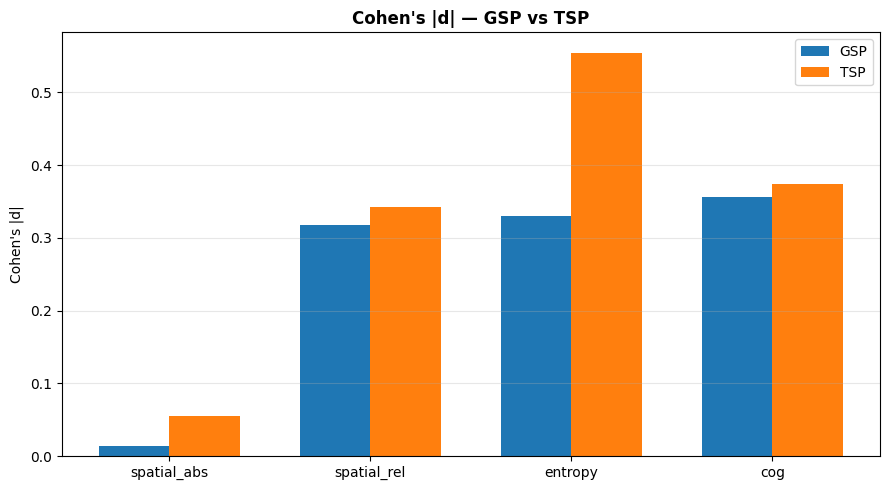


Cohen's d medio global — GSP: 0.2546  |  TSP: 0.3318


In [3]:
def cohens_d(group0, group1):
    n0, n1 = len(group0), len(group1)
    var0, var1 = group0.var(ddof=1), group1.var(ddof=1)
    sp = np.sqrt(((n0 - 1) * var0 + (n1 - 1) * var1) / (n0 + n1 - 2))
    if sp == 0:
        return 0.0
    return abs((group1.mean() - group0.mean()) / sp)

results_d_topo = {}

for name, df, feats in TOPO_TECHNIQUES:
    g0 = df[df['label'] == 0]
    g1 = df[df['label'] == 1]
    results_d_topo[name] = {feat: cohens_d(g0[feat], g1[feat]) for feat in feats}

print(f"{'Técnica':<10}{'Feature':<22}{'Cohen |d|':>12}")
print("-" * 44)
for name, df, feats in TOPO_TECHNIQUES:
    for feat in feats:
        marker = ' *' if (feat, name) in features_degeneradas_topo else ''
        print(f"{name:<10}{feat:<22}{results_d_topo[name][feat]:>12.4f}{marker}")

# ── Gráfico de barras ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
feat_labels = ['spatial_abs', 'spatial_rel', 'entropy', 'cog']
x = np.arange(len(feat_labels))
width = 0.35

for k, (name, df, feats) in enumerate(TOPO_TECHNIQUES):
    vals = [results_d_topo[name][f] for f in feats]
    offset = (k - 0.5) * width
    ax.bar(x + offset, vals, width, label=name)

ax.set_xticks(x)
ax.set_xticklabels(feat_labels)
ax.set_ylabel("Cohen's |d|")
ax.set_title("Cohen's |d| — GSP vs TSP", fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"\nCohen's d medio global — GSP: {np.mean(list(results_d_topo['GSP'].values())):.4f}"
      f"  |  TSP: {np.mean(list(results_d_topo['TSP'].values())):.4f}")


## Sección 2: Mann-Whitney $U$ — significancia estadística

Mismo test no paramétrico del notebook 05. Con 4 features × 2 técnicas =
8 pruebas totales (muchas menos que las 224 del notebook 05), la
corrección de Bonferroni es proporcionalmente menos severa:

$$\alpha_{corr} = \frac{0.05}{8} = 0.00625$$

In [4]:
ALPHA = 0.05
N_TESTS_TOPO = sum(len(feats) for _, _, feats in TOPO_TECHNIQUES)  # 4 + 4 = 8
ALPHA_CORR_TOPO = ALPHA / N_TESTS_TOPO

results_mw_topo = {}

for name, df, feats in TOPO_TECHNIQUES:
    g0 = df[df['label'] == 0]
    g1 = df[df['label'] == 1]
    results_mw_topo[name] = {}
    for feat in feats:
        _, p = mannwhitneyu(g0[feat], g1[feat], alternative='two-sided')
        results_mw_topo[name][feat] = p

print(f"Corrección Bonferroni: alpha = {ALPHA} / {N_TESTS_TOPO} = {ALPHA_CORR_TOPO:.5f}\n")
print(f"{'Técnica':<10}{'Feature':<22}{'p-value':>12}{'Significativo':>16}")
print("-" * 60)
for name, df, feats in TOPO_TECHNIQUES:
    for feat in feats:
        p = results_mw_topo[name][feat]
        sig = 'SI' if p < ALPHA_CORR_TOPO else 'No'
        marker = ' *' if (feat, name) in features_degeneradas_topo else ''
        print(f"{name:<10}{feat:<22}{p:>12.5f}{sig:>16}{marker}")


Corrección Bonferroni: alpha = 0.05 / 8 = 0.00625

Técnica   Feature                    p-value   Significativo
------------------------------------------------------------
GSP       GSP_spatial_abs            0.19871              No
GSP       GSP_spatial_rel            0.01096              No
GSP       GSP_entropy                0.00465              SI *
GSP       GSP_cog                    0.00516              SI
TSP       TSP_spatial_abs            0.25634              No
TSP       TSP_spatial_rel            0.00056              SI
TSP       TSP_entropy                0.00043              SI *
TSP       TSP_cog                    0.00033              SI


## Sección 3: Fisher's Discriminant Ratio (FDR)

$$\text{FDR} = \frac{(\mu_1 - \mu_0)^2}{s_0^2 + s_1^2}$$

Misma definición y mismo rol que en el notebook 05: cota superior de
rendimiento para un clasificador lineal usando esa feature en aislamiento.

Técnica   Feature                        FDR
--------------------------------------------
GSP       GSP_spatial_abs            0.00011
GSP       GSP_spatial_rel            0.05217
GSP       GSP_entropy                0.05626 *
GSP       GSP_cog                    0.06546
TSP       TSP_spatial_abs            0.00155
TSP       TSP_spatial_rel            0.05996
TSP       TSP_entropy                0.16150 *
TSP       TSP_cog                    0.07152


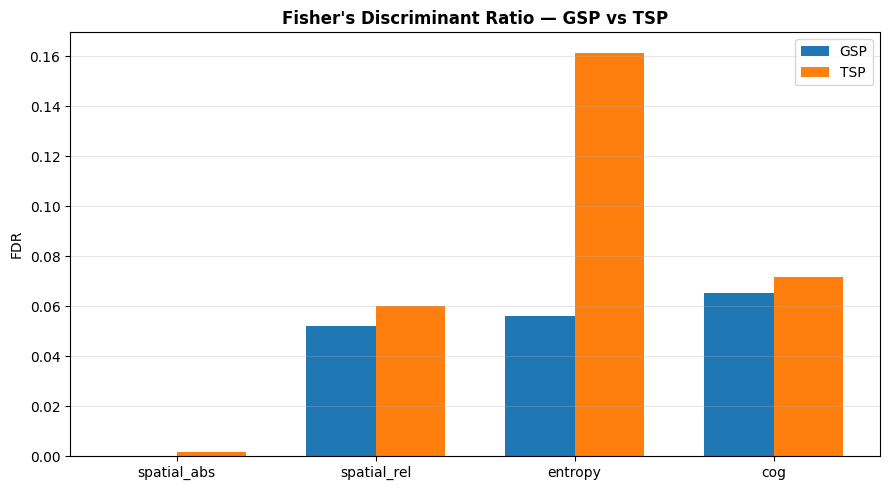


FDR medio global — GSP: 0.04350  |  TSP: 0.07363


In [5]:
def fishers_discriminant_ratio(group0, group1):
    num = (group1.mean() - group0.mean()) ** 2
    denom = group0.var(ddof=1) + group1.var(ddof=1)
    return float(num / denom) if denom > 0 else 0.0

results_fdr_topo = {}

for name, df, feats in TOPO_TECHNIQUES:
    g0 = df[df['label'] == 0]
    g1 = df[df['label'] == 1]
    results_fdr_topo[name] = {feat: fishers_discriminant_ratio(g0[feat], g1[feat]) for feat in feats}

print(f"{'Técnica':<10}{'Feature':<22}{'FDR':>12}")
print("-" * 44)
for name, df, feats in TOPO_TECHNIQUES:
    for feat in feats:
        marker = ' *' if (feat, name) in features_degeneradas_topo else ''
        print(f"{name:<10}{feat:<22}{results_fdr_topo[name][feat]:>12.5f}{marker}")

fig, ax = plt.subplots(figsize=(9, 5))
for k, (name, df, feats) in enumerate(TOPO_TECHNIQUES):
    vals = [results_fdr_topo[name][f] for f in feats]
    offset = (k - 0.5) * width
    ax.bar(x + offset, vals, width, label=name)
ax.set_xticks(x)
ax.set_xticklabels(feat_labels)
ax.set_ylabel('FDR')
ax.set_title('Fisher\'s Discriminant Ratio — GSP vs TSP', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"\nFDR medio global — GSP: {np.mean(list(results_fdr_topo['GSP'].values())):.5f}"
      f"  |  TSP: {np.mean(list(results_fdr_topo['TSP'].values())):.5f}")


## Sección 4: Mutual Information (MI)

Misma definición que en el notebook 05 — única métrica de este análisis
que captura dependencia no lineal entre feature y clase, sin asumir forma
funcional.

Técnica   Feature                  MI (nats)
--------------------------------------------
GSP       GSP_spatial_abs            0.07442
GSP       GSP_spatial_rel            0.05468
GSP       GSP_entropy                0.06550 *
GSP       GSP_cog                    0.03702
TSP       TSP_spatial_abs            0.00000
TSP       TSP_spatial_rel            0.08925
TSP       TSP_entropy                0.08734 *
TSP       TSP_cog                    0.08818


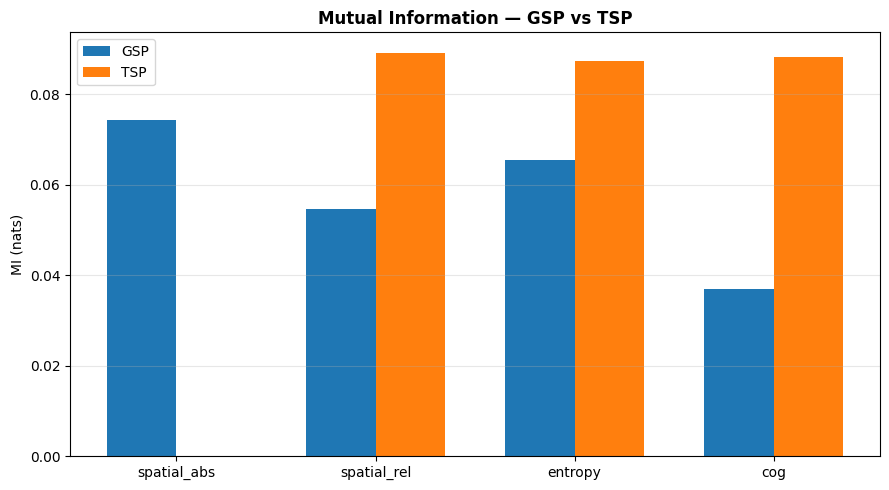


MI media global — GSP: 0.05791  |  TSP: 0.06619


In [6]:
results_mi_topo = {}

for name, df, feats in TOPO_TECHNIQUES:
    X = df[feats].values
    y = df['label'].values
    mi = mutual_info_classif(X, y, discrete_features=False, random_state=42)
    results_mi_topo[name] = dict(zip(feats, mi))

print(f"{'Técnica':<10}{'Feature':<22}{'MI (nats)':>12}")
print("-" * 44)
for name, df, feats in TOPO_TECHNIQUES:
    for feat in feats:
        marker = ' *' if (feat, name) in features_degeneradas_topo else ''
        print(f"{name:<10}{feat:<22}{results_mi_topo[name][feat]:>12.5f}{marker}")

fig, ax = plt.subplots(figsize=(9, 5))
for k, (name, df, feats) in enumerate(TOPO_TECHNIQUES):
    vals = [results_mi_topo[name][f] for f in feats]
    offset = (k - 0.5) * width
    ax.bar(x + offset, vals, width, label=name)
ax.set_xticks(x)
ax.set_xticklabels(feat_labels)
ax.set_ylabel('MI (nats)')
ax.set_title('Mutual Information — GSP vs TSP', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"\nMI media global — GSP: {np.mean(list(results_mi_topo['GSP'].values())):.5f}"
      f"  |  TSP: {np.mean(list(results_mi_topo['TSP'].values())):.5f}")


## Sección 5: GSP y TSP frente a las técnicas tiempo-frecuencia

Esta sección responde directamente la pregunta de partida: ¿qué tan
discriminativas son las features topológicas comparadas con STFT, CWT,
SST y WPD? Se reutilizan las mismas tres métricas (Cohen's $d$, FDR, MI),
calculadas con el mismo código del notebook 05 sobre los 4 datasets TF,
y se contrastan contra los promedios de GSP y TSP recién calculados.

Es una comparación *agregada* (promedio sobre las 4 features de cada
técnica) — no busca reemplazar el detalle por canal del notebook 05, sino
dar una referencia rápida de orden de magnitud: si GSP/TSP están muy por
debajo del promedio de las técnicas TF, su aporte marginal a un
clasificador que ya use TF sería cuestionable; si están en un rango
comparable (o si capturan algo que TF no captura, ver Sección 4 del
notebook 04b sobre correlación cruzada), el caso para incluirlas se
fortalece.

COMPARACIÓN GLOBAL — Topológicas (GSP, TSP) vs Tiempo-Frecuencia (STFT, CWT, SST, WPD)
                      Tipo  N features  Cohen's d medio  FDR medio  MI media
Técnica                                                                     
GSP             Topológica           4           0.2546     0.0435    0.0579
TSP             Topológica           4           0.3318     0.0736    0.0662
STFT     Tiempo-frecuencia          56           0.1478     0.0173    0.0144
CWT      Tiempo-frecuencia          56           0.2040     0.0332    0.0258
SST      Tiempo-frecuencia          56           0.2027     0.0320    0.0265
WPD      Tiempo-frecuencia          56           0.1655     0.0199    0.0184


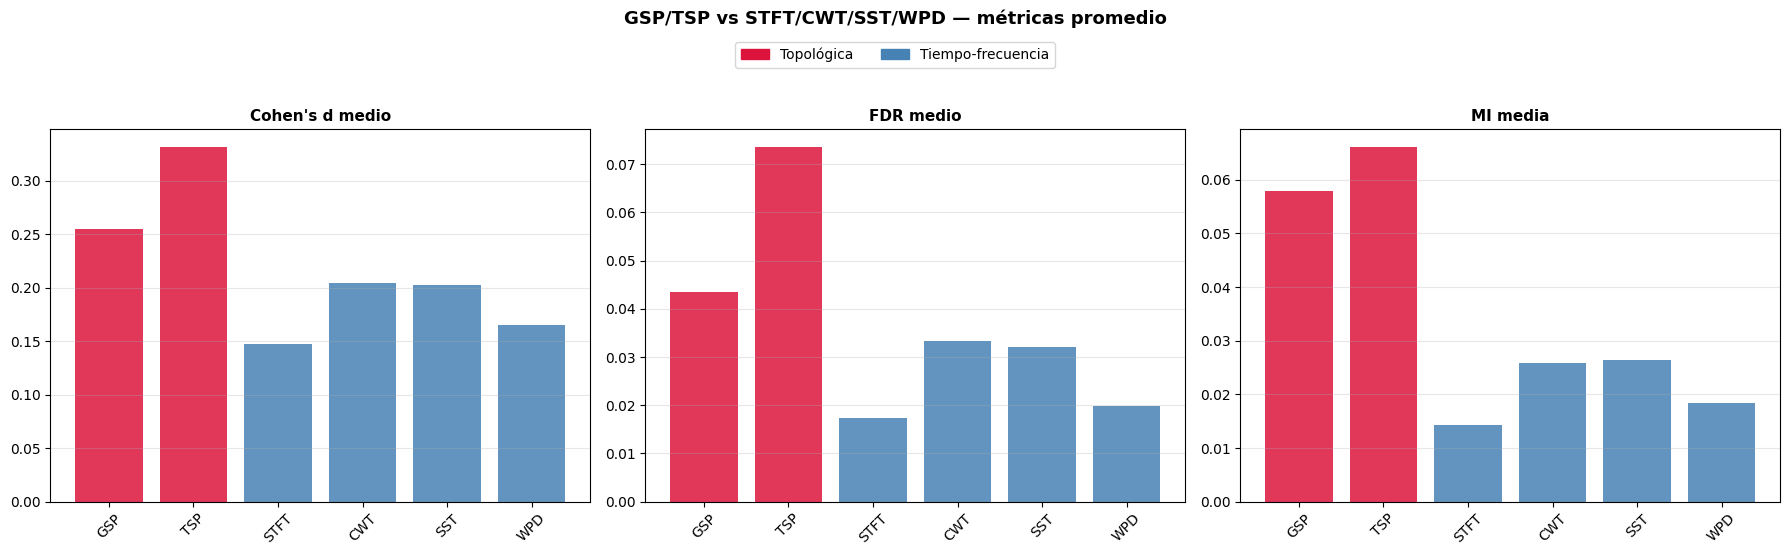

In [7]:
CHANNELS   = ['AF3','F7','F3','FC5','T7','P7','O1','O2','P8','T8','FC6','F4','F8','AF4']
TF_FEAT_NAMES = ['alpha_abs', 'alpha_rel', 'entropy', 'cog']
TF_COL_NAMES  = [f'{ch}_{f}' for ch in CHANNELS for f in TF_FEAT_NAMES]

tf_paths = {
    'STFT': STFT_PATH, 'CWT': CWT_PATH, 'SST': SST_PATH, 'WPD': WPD_PATH
}

resumen_global = []

# GSP y TSP ya calculados arriba
for name, _, feats in TOPO_TECHNIQUES:
    resumen_global.append({
        'Técnica': name,
        'Tipo': 'Topológica',
        'N features': len(feats),
        "Cohen's d medio": np.mean(list(results_d_topo[name].values())),
        'FDR medio':       np.mean(list(results_fdr_topo[name].values())),
        'MI media':        np.mean(list(results_mi_topo[name].values())),
    })

# TF: se recalculan aquí mismo para que este notebook sea autocontenido
# (mismo procedimiento que en el notebook 05, sin filtrar features degeneradas)
for name, path in tf_paths.items():
    if not Path(path).exists():
        print(f"(omitido {name}: no se encontró {path})")
        continue
    df_tf = pd.read_csv(path)
    g0 = df_tf[df_tf['label'] == 0]
    g1 = df_tf[df_tf['label'] == 1]

    d_vals, fdr_vals = [], []
    for col in TF_COL_NAMES:
        d_vals.append(cohens_d(g0[col], g1[col]))
        fdr_vals.append(fishers_discriminant_ratio(g0[col], g1[col]))

    X = df_tf[TF_COL_NAMES].values
    y = df_tf['label'].values
    mi_vals = mutual_info_classif(X, y, discrete_features=False, random_state=42)

    resumen_global.append({
        'Técnica': name,
        'Tipo': 'Tiempo-frecuencia',
        'N features': len(TF_COL_NAMES),
        "Cohen's d medio": np.mean(d_vals),
        'FDR medio':       np.mean(fdr_vals),
        'MI media':        np.mean(mi_vals),
    })

df_global = pd.DataFrame(resumen_global).set_index('Técnica')
print("=" * 80)
print("COMPARACIÓN GLOBAL — Topológicas (GSP, TSP) vs Tiempo-Frecuencia (STFT, CWT, SST, WPD)")
print("=" * 80)
print(df_global.to_string(float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else x))

# ── Gráfico comparativo ────────────────────────────────────────────────
if len(df_global) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    metricas_plot = [("Cohen's d medio", axes[0]), ('FDR medio', axes[1]), ('MI media', axes[2])]
    palette = {'Topológica': 'crimson', 'Tiempo-frecuencia': 'steelblue'}

    for metrica, ax in metricas_plot:
        bar_colors = [palette[t] for t in df_global['Tipo']]
        ax.bar(df_global.index, df_global[metrica], color=bar_colors, alpha=0.85)
        ax.set_title(metrica, fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        ax.tick_params(axis='x', rotation=45)

    handles = [plt.Rectangle((0,0),1,1, color=c) for c in palette.values()]
    fig.legend(handles, palette.keys(), loc='upper center', ncol=2,
               bbox_to_anchor=(0.5, 1.05))
    plt.suptitle('GSP/TSP vs STFT/CWT/SST/WPD — métricas promedio', fontsize=13,
                 fontweight='bold', y=1.1)
    plt.tight_layout()
    plt.show()


## Resumen de lo realizado en este notebook

Este notebook aplicó a las features topológicas (GSP, TSP) las mismas
cuatro métricas estadísticas usadas en el notebook 05 para las técnicas
tiempo-frecuencia:

1. **Verificación de degeneración** (coeficiente de variación).
2. **Cohen's $d$** — tamaño del efecto por feature.
3. **Mann-Whitney $U$** — significancia estadística, con corrección de
   Bonferroni ajustada al número real de pruebas (8, no 224).
4. **Fisher's Discriminant Ratio** — separabilidad lineal.
5. **Mutual Information** — informatividad no lineal.
6. **Comparación cuantitativa agregada** contra STFT, CWT, SST y WPD, en
   las tres métricas no degeneradas, para tener una referencia numérica
   directa de qué tan competitivas son GSP y TSP frente a las técnicas ya
   evaluadas.

Como este notebook tampoco se ha ejecutado aún contra los datos reales, no
se incluyen observaciones ni conclusiones — el código y las tablas/gráficos
están listos para correr y leer, pero la interpretación de los números
(qué técnica gana, si la diferencia es grande o marginal, si conviene
sumar GSP y/o TSP al pipeline de clasificación) queda pendiente hasta la
ejecución real.

### Lo que queda pendiente

Una vez ejecutados ambos notebooks (04b y 05b) contra los datos reales:

- Redactar las secciones de observaciones e interpretación, siguiendo el
  mismo nivel de detalle que en los notebooks 04 y 05.
- Decidir, con base en los resultados numéricos de la Sección 5, si GSP
  y/o TSP se incorporan como features adicionales en el notebook de
  clasificación (06), y si se usan en combinación con alguna técnica TF
  o de forma independiente.
- Si la correlación cruzada GSP-TSP calculada en el notebook 04b resulta
  alta, evaluar si conviene incluir ambas técnicas o solo una, para evitar
  redundancia innecesaria en el set final de features.